# Competencia  - Parte 1

Importación de librerias

In [ ]:
# Librerias base para cargar datos, guardar artefactos y trabajar con texto.
import json
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Configuracion visual para que las tablas y graficas se vean mejor en el notebook.
pd.set_option('display.max_colwidth', 140)
sns.set_theme(style='whitegrid')

# Parametros globales para hacer la corrida reproducible.
RANDOM_STATE = 42
VALIDATION_SIZE = 0.15

# Nombres de los archivos que se usan y se generan en la entrega.
train_path = 'train.csv'
eval_path = 'eval.csv'
submission_path = 'submission.csv'
model_path = 'modelo_final.joblib'
metrics_path = 'metricas_resumen.json'

print('Train:', train_path)
print('Eval:', eval_path)

Train: train.csv
Eval: eval.csv


## 1. Carga y validacion de los datos

En esta parte se leen los archivos  de la competencia y se valida que tengan el esquema esperado.
Tambien verificamos que no existan ids duplicados en `eval.csv`.

In [ ]:
# Cargamos los archivos originales de entrenamiento y evaluacion.
train_df = pd.read_csv(train_path)
eval_df = pd.read_csv(eval_path)

# Resumimos el esquema de los datos para confirmar tamano, nulos y rango de clases.
schema_info = pd.DataFrame([{
    'train_filas': int(train_df.shape[0]),
    'train_columnas': int(train_df.shape[1]),
    'eval_filas': int(eval_df.shape[0]),
    'eval_columnas': int(eval_df.shape[1]),
    'train_nulos_text': int(train_df['text'].isna().sum()),
    'train_nulos_decade': int(train_df['decade'].isna().sum()),
    'eval_nulos_id': int(eval_df['id'].isna().sum()),
    'eval_nulos_text': int(eval_df['text'].isna().sum()),
    'numero_de_clases': int(train_df['decade'].nunique()),
    'clase_minima': int(train_df['decade'].min()),
    'clase_maxima': int(train_df['decade'].max())
}])

display(schema_info)
display(train_df.head(3))
display(eval_df.head(3))

,train_filas,train_columnas,eval_filas,eval_columnas,train_nulos_text,train_nulos_decade,eval_nulos_id,eval_nulos_text,numero_de_clases,clase_minima,clase_maxima
0,31403,2,3490,2,0,0,0,0,39,150,188


,text,decade
0,"\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \nnes pa...",164
1,"gone. Sus amigos , sus clientes, todo \ncuanto le rodea le prueban que es hom- \nbre de mucha importancia. Si ve que al- \ngunos hombre»...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan feratormentados, e \nante quien,e quie preguntasles deuan hazer mientras los tormentarf, ...",157


,id,text
0,0,"P. Si en efta convocación trato folamente de comunicarles los artículos arregla- \ndos, y firmados, o de proponerles , qué ..."
1,1,"«Muy santo Padre : Ayer escribiá don Juan Man- \ny rique que dijese á vuestra Santidad, ó le escribie- \n»se, en cuán bucnos términos qu..."
2,2,"Recibo, otorgado por Diego Gracián a favor de Jerónimo Zurita, de un libro de Casiodoro, titulado \nDe Amicitia et Dilectione seu de Car..."


## 2. Exploracion del dataset

Antes de entrenar el modelo conviene revisar dos cosas:

- la distribucion de la variable objetivo `decade`;
- el tamano de los textos.

Esto ayuda a justificar el uso de una representacion por caracteres, que funciona bien cuando hay OCR ruidoso, grafias antiguas y variaciones ortograficas.

,frecuencia
decade,
150,786
151,812
152,785
153,775
154,830
155,836
156,792
157,827
158,778


,valor
count,31403.000000
mean,520.568290
std,530.947792
min,120.000000
10%,139.000000
25%,182.000000
50%,315.000000
75%,643.000000
90%,1198.000000
95%,1627.000000


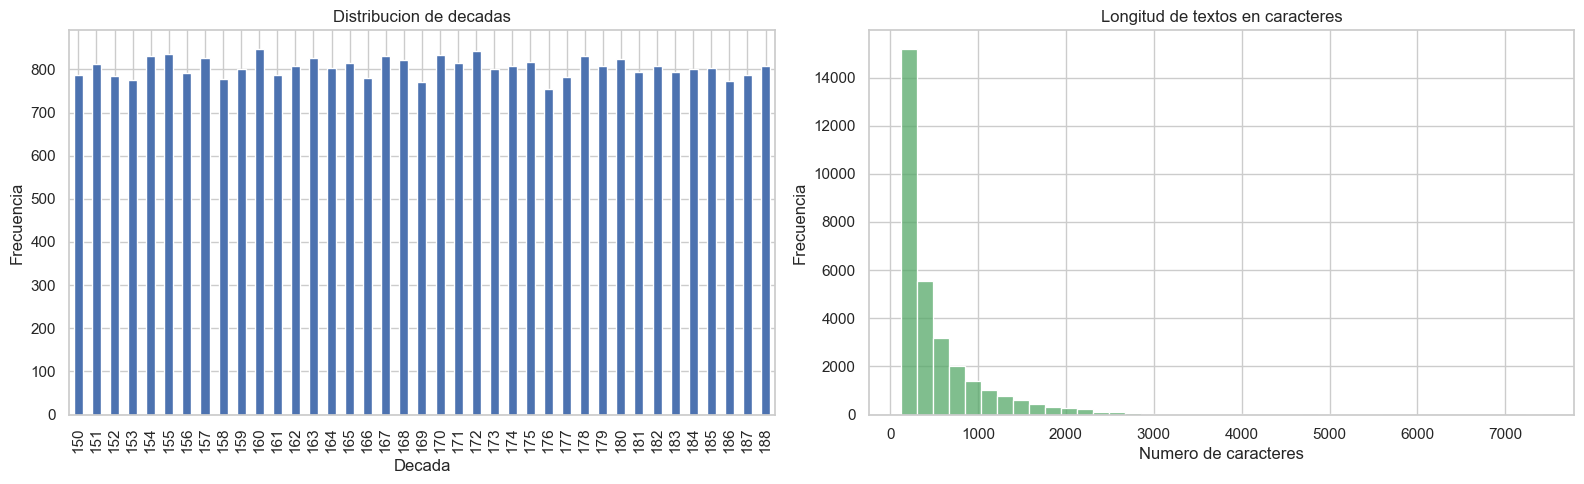

In [ ]:
# Calculamos la distribucion de clases y la longitud de los textos para una exploracion rapida.
class_counts = train_df['decade'].value_counts().sort_index()
text_lengths = train_df['text'].astype(str).map(len)
length_summary = text_lengths.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame(name='valor')

display(class_counts.to_frame(name='frecuencia').head(10))
display(length_summary)

# Graficamos ambas distribuciones para justificar la representacion por caracteres.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

class_counts.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribucion de decadas')
axes[0].set_xlabel('Decada')
axes[0].set_ylabel('Frecuencia')

sns.histplot(text_lengths, bins=40, ax=axes[1], color='#55A868')
axes[1].set_title('Longitud de textos en caracteres')
axes[1].set_xlabel('Numero de caracteres')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 3. Limpieza del texto

Solo hacemos una limpieza minima:

- convertir todo a `str`;
- normalizar saltos de linea y espacios repetidos;
- eliminar textos con etiquetas conflictivas;
- eliminar duplicados exactos del conjunto de entrenamiento.

In [ ]:
# Hacemos copias para limpiar sin alterar los datos originales cargados del disco.
clean_train_df = train_df.copy()
clean_eval_df = eval_df.copy()

# La limpieza es conservadora: normalizamos saltos de linea y espacios, pero preservamos senal historica.
clean_train_df['text'] = clean_train_df['text'].astype(str)
clean_train_df['text'] = clean_train_df['text'].str.replace('\r\n', '\n', regex=False)
clean_train_df['text'] = clean_train_df['text'].str.replace('\r', '\n', regex=False)
clean_train_df['text'] = clean_train_df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()
clean_train_df['decade'] = clean_train_df['decade'].astype(int)

clean_eval_df['text'] = clean_eval_df['text'].astype(str)
clean_eval_df['text'] = clean_eval_df['text'].str.replace('\r\n', '\n', regex=False)
clean_eval_df['text'] = clean_eval_df['text'].str.replace('\r', '\n', regex=False)
clean_eval_df['text'] = clean_eval_df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Guardamos el numero inicial de filas para reportar el efecto de la limpieza.
rows_before_cleaning = int(len(clean_train_df))

# Eliminamos textos con etiquetas conflictivas porque introducen ruido directo en el entrenamiento.
label_counts_per_text = clean_train_df.groupby('text')['decade'].nunique()
conflicting_texts = label_counts_per_text[label_counts_per_text > 1].index
conflicting_rows_removed = int(clean_train_df['text'].isin(conflicting_texts).sum())
clean_train_df = clean_train_df.loc[~clean_train_df['text'].isin(conflicting_texts)].copy()

# Eliminamos duplicados exactos restantes para no sobre-representar el mismo texto.
duplicate_rows_removed = int(clean_train_df.duplicated(subset=['text']).sum())
clean_train_df = clean_train_df.drop_duplicates(subset=['text']).reset_index(drop=True)

# Esta tabla muestra ejemplos de textos repetidos para documentar la calidad de los datos.
duplicate_preview = (
    train_df.assign(text=train_df['text'].astype(str).str.replace('\r\n', '\n', regex=False).str.replace('\r', '\n', regex=False).str.replace(r'\s+', ' ', regex=True).str.strip())
    .groupby('text')
    .agg(n=('text', 'size'), labels=('decade', lambda x: sorted(set(map(int, x)))))
    .sort_values('n', ascending=False)
    .head(10)
    .reset_index()
)

# Resumimos el impacto de la limpieza para dejarlo documentado en la entrega.
cleaning_report = pd.DataFrame([{
    'filas_antes_de_limpiar': rows_before_cleaning,
    'filas_con_etiquetas_conflictivas_eliminadas': conflicting_rows_removed,
    'filas_duplicadas_eliminadas': duplicate_rows_removed,
    'filas_despues_de_limpiar': int(len(clean_train_df)),
    'numero_de_clases_final': int(clean_train_df['decade'].nunique()),
    'filas_eval_limpio': int(len(clean_eval_df))
}])

display(cleaning_report)
display(duplicate_preview)

print('Clases antes de limpiar:', train_df['decade'].nunique())
print('Clases despues de limpiar:', clean_train_df['decade'].nunique())

,filas_antes_de_limpiar,filas_con_etiquetas_conflictivas_eliminadas,filas_duplicadas_eliminadas,filas_despues_de_limpiar,numero_de_clases_final,filas_eval_limpio
0,31403,43,34,31326,39,3490


,text,n,labels
0,It has survived long enough for the copyright to expire and the book to enter the public domain. A public domain book is one that was ne...,4,"[151, 154, 179, 182]"
1,"+ Manténgase siempre dentro de la legalidad Sea cual sea el uso que haga de estos materiales, recuerde que es responsable de asegurarse ...",3,"[155, 166, 181]"
2,"Early European Books, Copyright© 201 1 ProQuest LLC. Images reproduced by courtesy of The Wellcome Trust, London. 257/A",3,[158]
3,"Early European Books, Copyright© 201 1 ProQuest LLC. Images reproduced by courtesy of The Wellcome Trust, London. 2447/A/l",3,[155]
4,"+ Make non-commercial use of the files We designed Google Book Search for use by individuáis, and we request that you use these files fo...",3,"[162, 179, 188]"
5,"+ Keep it legal Whatever your use, remember that you are lesponsible for ensuring that what you are doing is legal. Do not assume that j...",3,"[175, 180, 186]"
6,"Marks, notations and other maiginalia present in the original volume will appear in this file - a reminder of this book's long journcy f...",3,"[174, 178, 182]"
7,Ha sobrevivido tantos años como para que los derechos de autor hayan expirado y el libro pase a ser de dominio público. El que un libro ...,3,"[182, 184, 186]"
8,This is a digital copy of a book that was prcscrvod for gcncrations on library shclvcs bcforc it was carcfully scannod by Google as parí...,3,"[180, 184, 186]"
9,"puertas hacia el pasado, suponen un patrimonio histórico, cultural y de conocimientos que, a menudo, resulta difícil de descubrir.",3,"[180, 187]"


Clases antes de limpiar: 39
Clases despues de limpiar: 39


## 4. Partición de entrenamiento y validación

Para revisar el modelo antes de entrenarlo sobre todo el dataset, hacemos una particion estratificada `85/15`.
Sirve para controlar que el modelo este funcionando bien antes de exportarlo.

In [ ]:
# Separamos un conjunto de validacion local estratificado para estimar el rendimiento antes de Kaggle.
x_train, x_valid, y_train, y_valid = train_test_split(
    clean_train_df['text'],
    clean_train_df['decade'],
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=clean_train_df['decade']
)

print('Filas de train local:', x_train.shape[0])
print('Filas de validacion local:', x_valid.shape[0])

Filas de train local: 26627
Filas de validacion local: 4699


## 5. Entrenamiento del modelo


La configuracion elegida fue:

- `TfidfVectorizer` por caracteres;
- `ngram_range=(2, 5)`;
- `min_df=1`;
- `max_features=350000`;
- `SGDClassifier(loss='log_loss', alpha=7e-6, penalty='l2', max_iter=3000, average=True)`.


,modelo,train_accuracy,valid_accuracy
0,char_tfidf_sgd_final,0.997559,0.292615


,vectorizer__analyzer,vectorizer__ngram_range,vectorizer__min_df,vectorizer__max_features,vectorizer__sublinear_tf,vectorizer__lowercase,model__name,model__loss,model__alpha,model__penalty,model__max_iter,model__average
0,char,"(2, 5)",1,350000,True,False,SGDClassifier,log_loss,0.000007,l2,3000,True


              precision    recall  f1-score   support

         150       0.82      0.81      0.81       118
         151       0.57      0.72      0.64       120
         152       0.66      0.62      0.64       117
         153       0.58      0.76      0.66       115
         154       0.54      0.60      0.57       124
         155       0.47      0.37      0.41       125
         156       0.33      0.31      0.32       119
         157       0.28      0.35      0.31       124
         158       0.27      0.30      0.28       116
         159       0.25      0.34      0.29       120
         160       0.15      0.13      0.14       127
         161       0.14      0.15      0.15       118
         162       0.26      0.24      0.25       121
         163       0.19      0.17      0.18       124
         164       0.24      0.24      0.24       121
         165       0.09      0.08      0.09       122
         166       0.14      0.09      0.11       117
         167       0.23    

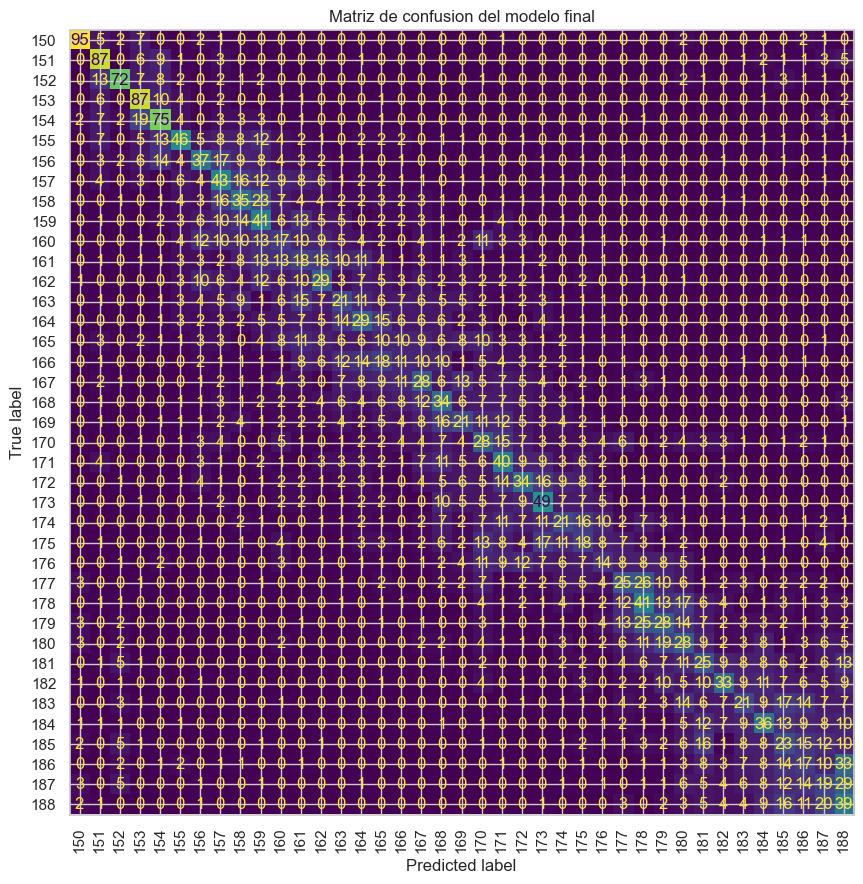

In [ ]:
# Construimos el pipeline final TF-IDF por caracteres seguido de un clasificador lineal SGD.
final_model = Pipeline([
    ('vectorizer', TfidfVectorizer(
        analyzer='char',
        ngram_range=(2, 5),
        min_df=1,
        max_features=350000,
        sublinear_tf=True,
        strip_accents=None,
        lowercase=False
    )),
    ('model', SGDClassifier(
        loss='log_loss',
        alpha=7e-6,
        penalty='l2',
        max_iter=3000,
        random_state=RANDOM_STATE,
        average=True
    ))
])

# Entrenamos el modelo sobre el train local.
final_model.fit(x_train, y_train)

# Generamos predicciones en train y validacion para medir ajuste y generalizacion.
y_train_pred = final_model.predict(x_train)
y_valid_pred = final_model.predict(x_valid)

# Calculamos metricas de resumen y la matriz de confusion para analizar el comportamiento por clase.
train_accuracy = float(accuracy_score(y_train, y_train_pred))
valid_accuracy = float(accuracy_score(y_valid, y_valid_pred))
classification_text = classification_report(y_valid, y_valid_pred, zero_division=0)
classification_dict = classification_report(y_valid, y_valid_pred, output_dict=True, zero_division=0)
confusion = confusion_matrix(y_valid, y_valid_pred, labels=sorted(y_valid.unique()))

# Guardamos un resumen corto del resultado del modelo final.
model_summary = pd.DataFrame([{
    'modelo': 'char_tfidf_sgd_final',
    'train_accuracy': train_accuracy,
    'valid_accuracy': valid_accuracy
}])

# Dejamos documentada la configuracion exacta para que la solucion sea replicable.
best_params = pd.DataFrame([{
    'vectorizer__analyzer': 'char',
    'vectorizer__ngram_range': (2, 5),
    'vectorizer__min_df': 1,
    'vectorizer__max_features': 350000,
    'vectorizer__sublinear_tf': True,
    'vectorizer__lowercase': False,
    'model__name': 'SGDClassifier',
    'model__loss': 'log_loss',
    'model__alpha': 7e-6,
    'model__penalty': 'l2',
    'model__max_iter': 3000,
    'model__average': True
}])

display(model_summary)
display(best_params)
print(classification_text)

# Visualizamos la matriz de confusion para identificar clases faciles y dificiles.
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(confusion, display_labels=sorted(y_valid.unique())).plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)
ax.set_title('Matriz de confusion del modelo final')
plt.tight_layout()
plt.show()

## 6. Interpretacion del modelo

Como el clasificador final es lineal, podemos inspeccionar algunos n-gramas de caracteres con coeficientes altos para cada decada.

No cambia el modelo, pero nos ayuda a mostrar que la solucion es interpretable y que realmente esta aprendiendo patrones del texto.

In [ ]:
# Extraemos el vectorizador y el clasificador para interpretar los n-gramas mas influyentes.
vectorizer = final_model.named_steps['vectorizer']
classifier = final_model.named_steps['model']
feature_names = np.asarray(vectorizer.get_feature_names_out())

# Recorremos cada decada y guardamos los 10 n-gramas con coeficientes mas altos.
top_features_rows = []
for class_index, class_label in enumerate(classifier.classes_):
    class_coefficients = classifier.coef_[class_index]
    top_indices = np.argsort(class_coefficients)[-10:][::-1]
    for rank, feature_index in enumerate(top_indices, start=1):
        feature_value = str(feature_names[feature_index])
        top_features_rows.append({
            'decade': int(class_label),
            'rank': rank,
            'feature': feature_value,
            'feature_visible': repr(feature_value),
            'n_chars': len(feature_value),
            'coefficient': float(class_coefficients[feature_index])
        })

# Convertimos la interpretacion a tabla para mostrar una muestra en el notebook.
# La columna feature_visible deja ver espacios u otros caracteres que en la tabla normal pueden ocultarse.
top_features = pd.DataFrame(top_features_rows)
display(top_features[['decade', 'rank', 'feature_visible', 'n_chars', 'coefficient']].head(50))

,decade,rank,feature_visible,n_chars,coefficient
0,150,1,' a ',3,3.456973
1,150,2,'Car',3,3.432796
2,150,3,'Carta',5,3.339763
3,150,4,'arta ',5,3.030555
4,150,5,'Cart',4,2.976352
5,150,6,'rta d',5,2.960104
6,150,7,'rey ',4,2.893553
7,150,8,'4t',2,2.853819
8,150,9,' rey ',5,2.705231
9,150,10,'oo',2,2.660144


## 7. Entrenamiento final con todo el conjunto limpio y exportacion

En este ultimo paso se reentrena el mismo modelo sobre todo `train.csv` ya limpio. Luego se generan los artefactos de la entrega:

- `submission.csv`;
- `modelo_final.joblib`;


In [ ]:
# Reentrenamos exactamente el mismo modelo usando todo el conjunto limpio.
final_model.fit(clean_train_df['text'], clean_train_df['decade'])
final_predictions = final_model.predict(clean_eval_df['text'])

# Construimos el archivo submission con el formato exigido por la competencia.
submission_df = pd.DataFrame({
    'id': clean_eval_df['id'],
    'answer': final_predictions.astype(int)
})

# Validamos que el numero de predicciones coincida con el archivo eval.
if len(submission_df) != len(clean_eval_df):
    raise ValueError('El submission no tiene el mismo numero de filas que eval.csv.')

# Guardamos el submission y el modelo final entrenado.
submission_df.to_csv(submission_path, index=False)
joblib.dump(final_model, model_path)

# Guardamos un resumen de metricas y configuracion para documentar la solucion final.
metrics_payload = {
    'schema_report': schema_info.to_dict(orient='records')[0],
    'cleaning_report': cleaning_report.to_dict(orient='records')[0],
    'best_model_name': 'char_tfidf_sgd_final',
    'best_source': 'modelo_final_para_entrega',
    'best_params': best_params.to_dict(orient='records')[0],
    'best_valid_accuracy': valid_accuracy,
    'validation_report': classification_dict,
    'top_features_preview': top_features.head(40).to_dict(orient='records'),
    'submission_rows': int(len(submission_df)),
    'prediction_min': int(submission_df['answer'].min()),
    'prediction_max': int(submission_df['answer'].max())
}

# Exportamos el resumen a JSON para dejar evidencia reproducible de la corrida final.
with open(metrics_path, 'w', encoding='utf-8') as metrics_file:
    json.dump(metrics_payload, metrics_file, indent=2, ensure_ascii=False)

display(submission_df.head())
print(f'Submission guardado en: {submission_path}')
print(f'Modelo guardado en: {model_path}')
print(f'Metricas guardadas en: {metrics_path}')
print(f'Filas del submission: {len(submission_df)}')
print(f"Rango de clases predichas: {int(submission_df['answer'].min())} - {int(submission_df['answer'].max())}")

,id,answer
0,0,173
1,1,185
2,2,150
3,3,169
4,4,153


Submission guardado en: submission.csv
Modelo guardado en: modelo_final.joblib
Metricas guardadas en: metricas_resumen.json
Filas del submission: 3490
Rango de clases predichas: 150 - 188
